# Advertising Click-Through Rate Prediction

This project predicts whether an online advertisement will be clicked, using the Avazu CTR dataset.

The workflow includes:
- Data loading and cleaning
- Exploratory data analysis
- Feature engineering: one-hot encoding for low-cardinality features, frequency encoding for high-cardinality features
- Handling class imbalance (the dataset has a much lower click rate than non-click rate)
- Logistic Regression baseline and XGBoost model, both imbalance-aware
- Lightweight hyperparameter search for XGBoost
- Model comparison using ROC-AUC, PR-AUC, and Log Loss
- XGBoost feature importance analysis

**Dataset size:** 404,290 advertising impressions

**Data source:** [Avazu Click-Through Rate Prediction (Kaggle)](https://www.kaggle.com/c/avazu-ctr-prediction). Download `train.csv` (or the filtered subset used here) and update `DATA_PATH` below.


## 1. Setup and Data Loading

The dataset is loaded with `id` stored as a string so the identifier is not interpreted as a numeric feature.
The original index-like `Unnamed: 0` column is removed before analysis.

`DATA_PATH` is set relative to the repo (`data/filtered_train.csv`) instead of a personal Google Drive path, so this notebook can be re-run by anyone who clones the repo and drops the CSV into `data/`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score, precision_recall_curve

from xgboost import XGBClassifier

RANDOM_STATE = 42

# Update this path if the dataset is stored elsewhere.
# Expected location after cloning this repo: data/filtered_train.csv
DATA_PATH = "/content/drive/MyDrive/train_data/filtered_train.csv"

df = pd.read_csv(DATA_PATH, dtype={"id": str})

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (404290, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.1074508552284609e+19,0,14102101,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,0,20352,320,50,2333,0,39,-1,157
1,1.2400122415769848e+19,0,14102103,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15701,320,50,1722,0,35,100084,79
2,1.0598011031664306e+19,0,14102103,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,1,0,17614,320,50,1993,2,1063,-1,33
3,1.8442185676315005e+18,0,14102104,1005,1,856e6d3f,58a89a43,f028772b,ecad2386,7801e8d9,...,1,0,16208,320,50,1800,3,167,100075,23
4,1.2360159177072531e+19,1,14102103,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,1,0,17614,320,50,1993,2,1063,-1,33


## 2. Dataset Overview

In [3]:
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Overall CTR:", df["click"].mean())
print("Unique IDs:", df["id"].nunique())
print("Duplicate IDs:", df["id"].duplicated().sum())

# The class imbalance matters a lot for how we train and evaluate models below.
click_counts = df["click"].value_counts()
print("\nClass balance:")
print(click_counts)
print("Positive (click) rate: {:.2%}".format(df["click"].mean()))


Rows: 404290
Columns: 24
Overall CTR: 0.16981622102945906
Unique IDs: 402586
Duplicate IDs: 1704

Class balance:
click
0    335635
1     68655
Name: count, dtype: int64
Positive (click) rate: 16.98%


## 3. Exploratory Data Analysis

### CTR by Banner Position

In [4]:
banner_summary = df.groupby("banner_pos")["click"].agg(["count", "mean"])
banner_summary


,count,mean
banner_pos,,
0,291180,0.164637
1,112416,0.182732
2,111,0.108108
3,20,0.250000
4,69,0.173913
5,57,0.105263
7,437,0.318078


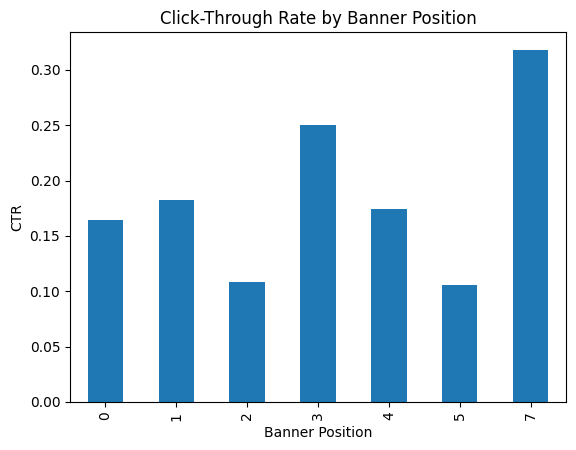

In [5]:
banner_summary["mean"].plot(kind="bar")

plt.title("Click-Through Rate by Banner Position")
plt.xlabel("Banner Position")
plt.ylabel("CTR")
plt.show()


### CTR by Hour of Day

The hour-of-day feature is extracted from the original `hour` field.

In [6]:
df["hour_of_day"] = df["hour"].astype(str).str[-2:].astype(int)

hour_summary = df.groupby("hour_of_day")["click"].agg(["count", "mean"])
hour_summary


,count,mean
hour_of_day,,
0,8531,0.184269
1,9928,0.182413
2,12282,0.173750
3,14112,0.172619
4,18990,0.162665
5,19625,0.162701
6,17741,0.172369
7,18637,0.179535
8,20991,0.161355


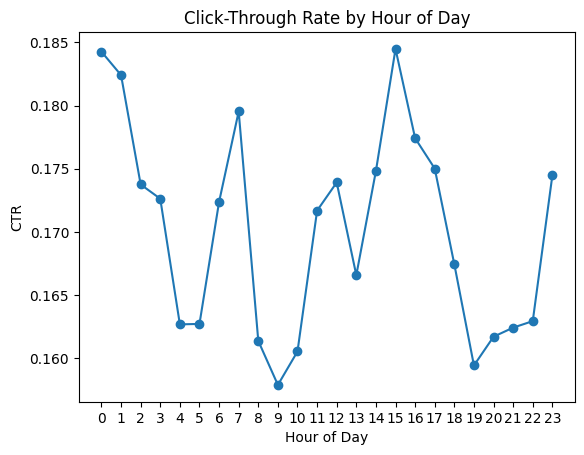

In [7]:
hour_summary["mean"].plot(kind="line", marker="o")

plt.title("Click-Through Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("CTR")
plt.xticks(range(24))
plt.show()


### Cardinality of Categorical Features

Before deciding how to encode each column, it's worth checking how many unique values each one has.
Low-cardinality columns are safe to one-hot encode. High-cardinality columns (site/app/device identifiers)
would blow up the feature space with one-hot encoding, so they need a different treatment — see Section 4.

In [8]:
candidate_cols = [
    "site_id", "site_domain", "site_category",
    "app_id", "app_domain", "app_category",
    "device_id", "device_ip", "device_model", "device_type", "device_conn_type",
    "banner_pos", "C1", "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21"
]

cardinality = df[candidate_cols].nunique().sort_values(ascending=False)
cardinality


,0
device_ip,261706
device_id,64742
device_model,4380
app_id,2241
site_id,2225
site_domain,2188
C14,2088
C17,411
C20,161
app_domain,143


## 4. Feature Preparation

**Low-cardinality categorical features** (a few to a few hundred unique values) are one-hot encoded, same as before.

**High-cardinality identifier features** (`site_id`, `app_id`, `device_id`, `device_ip`, `device_model`, `site_domain`)
can have thousands to hundreds of thousands of unique values. One-hot encoding these would be both
computationally expensive and prone to overfitting on rare categories. Instead they're **frequency-encoded**:
each category is replaced by how often it appears in the *training* data. This is fit only on the training
set and then applied to the test set, so information about the test set never leaks into training — categories
seen only at test time simply get a frequency of 0.

These identifier features are usually where a lot of the real predictive signal lives in CTR problems (they
capture per-site / per-app / per-device click-propensity), so adding them is expected to meaningfully improve
on the low-cardinality-only baseline from the original version of this notebook.


In [9]:
df = df.drop(columns=["id", "hour"])

low_card_cols = [
    "site_category",
    "app_category",
    "device_type",
    "device_conn_type",
    "banner_pos",
    "hour_of_day",
    "C1",
    "C15",
    "C16",
    "C18",
]

high_card_cols = [
    "site_id",
    "site_domain",
    "app_id",
    "app_domain",
    "device_id",
    "device_ip",
    "device_model",
    "C14",
    "C17",
    "C19",
    "C20",
    "C21",
]

feature_cols = low_card_cols + high_card_cols

X = df[feature_cols]
y = df["click"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train CTR:", y_train.mean())
print("Test CTR:", y_test.mean())


X_train: (323432, 22)
X_test: (80858, 22)
Train CTR: 0.16981622102945906
Test CTR: 0.16981622102945906


In [10]:
class FrequencyEncoder:
    """Replaces each category with its frequency in the training data.

    Fit only on training data to avoid leakage. Categories unseen during
    fit (e.g. new site_id values at test time) are encoded as 0.
    """

    def __init__(self, cols):
        self.cols = cols
        self.freq_maps_ = {}

    def fit(self, X, y=None):
        for col in self.cols:
            self.freq_maps_[col] = X[col].value_counts(normalize=True)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X[col].map(self.freq_maps_[col]).fillna(0.0)
        return X[self.cols]


freq_encoder = FrequencyEncoder(cols=high_card_cols)
X_train_freq = freq_encoder.fit(X_train).transform(X_train)
X_test_freq = freq_encoder.transform(X_test)

print("Frequency-encoded train shape:", X_train_freq.shape)
X_train_freq.head()


Frequency-encoded train shape: (323432, 12)


,site_id,site_domain,app_id,app_domain,device_id,device_ip,device_model,C14,C17,C19,C20,C21
322766,0.160086,0.160086,0.637840,0.672410,0.825351,0.000003,0.000028,0.011999,0.111223,0.301111,0.059945,0.113838
390757,0.006969,0.006969,0.637840,0.672410,0.825351,0.000006,0.018829,0.013570,0.013688,0.020156,0.038138,0.219054
301602,0.362160,0.375340,0.000767,0.130179,0.825351,0.000006,0.016297,0.001107,0.006419,0.023643,0.468596,0.006984
278464,0.000068,0.000071,0.637840,0.672410,0.000003,0.000003,0.000931,0.001784,0.004931,0.218278,0.011560,0.219054
338425,0.002276,0.002399,0.637840,0.672410,0.825351,0.000003,0.000451,0.000257,0.009288,0.005200,0.003970,0.025727


In [11]:
onehot = OneHotEncoder(handle_unknown="ignore")

X_train_onehot = onehot.fit_transform(X_train[low_card_cols])
X_test_onehot = onehot.transform(X_test[low_card_cols])

from scipy.sparse import hstack, csr_matrix

X_train_processed = hstack([X_train_onehot, csr_matrix(X_train_freq.values)]).tocsr()
X_test_processed = hstack([X_test_onehot, csr_matrix(X_test_freq.values)]).tocsr()

feature_names = list(onehot.get_feature_names_out(low_card_cols)) + high_card_cols

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed training shape: (323432, 127)
Processed test shape: (80858, 127)


## 5. Handling Class Imbalance

The click rate is well under 50%, so a model that ignores this will lean toward predicting "no click" and
still look accurate while being nearly useless at ranking likely clicks. Two adjustments:

- **Logistic Regression**: `class_weight="balanced"` reweights the loss inversely proportional to class frequency.
- **XGBoost**: `scale_pos_weight` (ratio of negative to positive examples) does the equivalent for gradient boosting.

We also report **PR-AUC** (average precision) alongside ROC-AUC. With imbalanced classes, ROC-AUC can look
deceptively good while precision on the minority (click) class is still poor — PR-AUC is more sensitive to that.


In [12]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Negative examples: {neg}, Positive examples: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


Negative examples: 268508, Positive examples: 54924
scale_pos_weight: 4.89


## 6. Logistic Regression Baseline

In [13]:
log_model = LogisticRegression(
    solver="saga",
    max_iter=500,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

log_model.fit(X_train_processed, y_train)

log_pred_prob = log_model.predict_proba(X_test_processed)[:, 1]

log_auc = roc_auc_score(y_test, log_pred_prob)
log_pr_auc = average_precision_score(y_test, log_pred_prob)
log_loss_value = log_loss(y_test, log_pred_prob)

print("Logistic Regression ROC-AUC:", log_auc)
print("Logistic Regression PR-AUC:", log_pr_auc)
print("Logistic Regression Log Loss:", log_loss_value)


Logistic Regression ROC-AUC: 0.6699415139727387
Logistic Regression PR-AUC: 0.2961983341835154
Logistic Regression Log Loss: 0.6451605582865256


## 7. XGBoost Model

XGBoost is used as a nonlinear model to capture relationships and interactions that Logistic Regression may
not represent. `scale_pos_weight` is set from the training class balance computed above.

In [14]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

xgb_pred_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_pred_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_pred_prob)
xgb_loss_value = log_loss(y_test, xgb_pred_prob)

print("XGBoost ROC-AUC:", xgb_auc)
print("XGBoost PR-AUC:", xgb_pr_auc)
print("XGBoost Log Loss:", xgb_loss_value)


XGBoost ROC-AUC: 0.7236369681854117
XGBoost PR-AUC: 0.34899699786890787
XGBoost Log Loss: 0.5917524569285859


## 8. Lightweight Hyperparameter Search

Rather than hand-picking XGBoost's hyperparameters, a small randomized search is run over the parameters
most likely to matter (tree depth, learning rate, number of trees, subsampling). This uses 3-fold
stratified cross-validation on the training set only, scored on ROC-AUC, so the held-out test set stays
untouched until final evaluation.

This is intentionally a small search (a handful of candidates) to keep runtime reasonable — the goal is to
show a defensible, reproducible tuning process, not to exhaustively grid search.


In [15]:
param_distributions = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "n_estimators": [200, 300, 400],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
}

base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_processed, y_train)

print("Best CV ROC-AUC:", search.best_score_)
print("Best params:", search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV ROC-AUC: 0.7382312797310825
Best params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [16]:
xgb_tuned = search.best_estimator_
xgb_tuned_pred_prob = xgb_tuned.predict_proba(X_test_processed)[:, 1]

xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_pred_prob)
xgb_tuned_pr_auc = average_precision_score(y_test, xgb_tuned_pred_prob)
xgb_tuned_loss_value = log_loss(y_test, xgb_tuned_pred_prob)

print("Tuned XGBoost ROC-AUC:", xgb_tuned_auc)
print("Tuned XGBoost PR-AUC:", xgb_tuned_pr_auc)
print("Tuned XGBoost Log Loss:", xgb_tuned_loss_value)


Tuned XGBoost ROC-AUC: 0.727114294368502
Tuned XGBoost PR-AUC: 0.3489365792290277
Tuned XGBoost Log Loss: 0.5777709780177823


## 9. Model Comparison

In [17]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost (default params)", "XGBoost (tuned)"],
    "ROC-AUC": [log_auc, xgb_auc, xgb_tuned_auc],
    "PR-AUC": [log_pr_auc, xgb_pr_auc, xgb_tuned_pr_auc],
    "Log Loss": [log_loss_value, xgb_loss_value, xgb_tuned_loss_value]
})

model_results


,Model,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.669942,0.296198,0.645161
1,XGBoost (default params),0.723637,0.348997,0.591752
2,XGBoost (tuned),0.727114,0.348937,0.577771


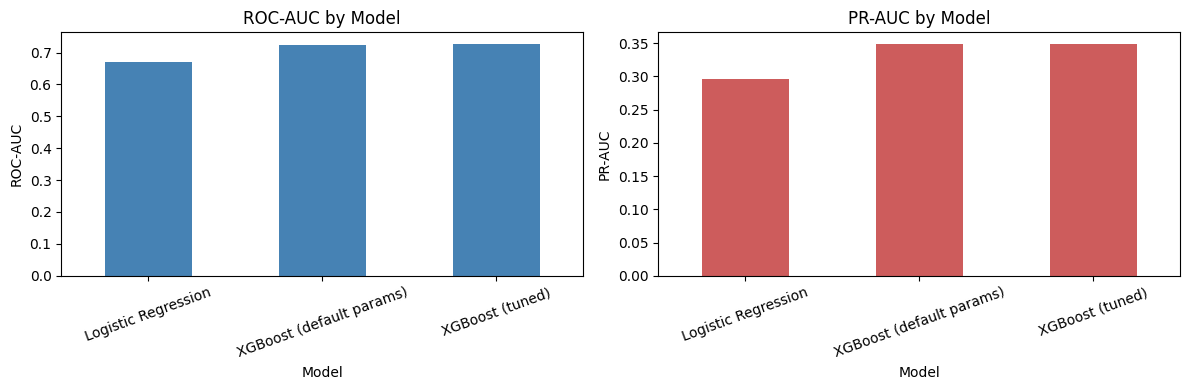

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_results.plot(x="Model", y="ROC-AUC", kind="bar", legend=False, ax=axes[0], color="steelblue")
axes[0].set_title("ROC-AUC by Model")
axes[0].set_ylabel("ROC-AUC")
axes[0].tick_params(axis="x", rotation=20)

model_results.plot(x="Model", y="PR-AUC", kind="bar", legend=False, ax=axes[1], color="indianred")
axes[1].set_title("PR-AUC by Model")
axes[1].set_ylabel("PR-AUC")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 10. XGBoost Feature Importance

Using the tuned model to see which features drive predictions — including how the frequency-encoded
high-cardinality identifiers (site/app/device) rank against the one-hot low-cardinality features.

In [19]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_tuned.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)


,feature,importance
113,C18_2,0.143613
112,C18_1,0.131419
106,C16_250,0.090447
104,C16_50,0.042505
88,C1_1002,0.025197
48,device_type_0,0.023806
126,C21,0.020640
89,C1_1005,0.016686
62,banner_pos_7,0.015942
43,app_category_cef3e649,0.014419


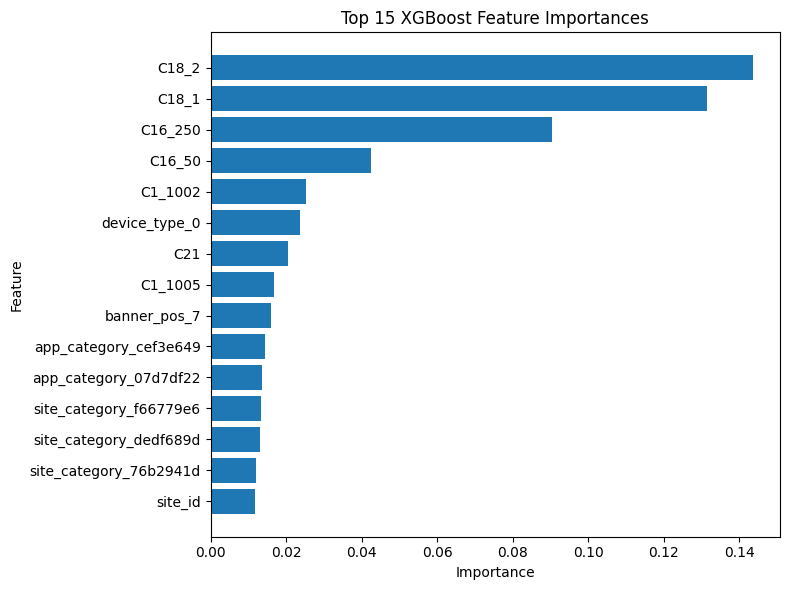

In [20]:
top_features = importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 11. Conclusion


Three approaches were evaluated for click-through rate prediction. As shown in the results table above, XGBoost clearly outperforms the Logistic Regression baseline, improving ROC-AUC from 0.670 to 0.727 and reducing log loss from 0.645 to 0.578. Notably, the model's PR-AUC of 0.349 is roughly 2x the base click rate of about 17 percent, indicating the model has meaningfully learned to rank likely clicks above random. Hyperparameter tuning produced only a small further improvement in ROC-AUC, from 0.724 to 0.727, suggesting the model is close to the performance ceiling achievable with the current feature set, rather than being limited by suboptimal hyperparameters.

The feature importance results were somewhat unexpected. The top-ranked features were not the newly added high-cardinality identifiers site_id, app_id, and device_id, but rather Avazu's anonymized contextual features C18 and C16, which are likely related to ad position and size, along with device type and browser category from C1. This suggests that in this dataset, the context and environment in which an ad is shown is a stronger predictor of clicks than which specific site or app it is shown on. The frequency-encoded site_id, app_id, and site_domain features still ranked within the top 20, but with modest importance, likely because a single frequency value does not fully capture each site's unique click propensity, especially for sites that are relatively rare in the training data.

A natural next step would be to try target encoding rather than frequency encoding for site_id and app_id to better capture per-site click propensity, and to construct interaction features such as site_id combined with device_type to recover more predictive signal from the identifier fields.